In [2]:
import torch
import numpy as np
import torch.nn as nn
import math
import matplotlib.pyplot as plt
torch.manual_seed(7)
torch.set_printoptions(precision=6, sci_mode=False)
print(f"PyTorch (torch.__version__) | device: CPU")

PyTorch (torch.__version__) | device: CPU


In [3]:
torch.empty(2,3)

tensor([[-0.000000,  0.000000,  0.000000],
        [ 0.000000, -0.000000,  0.000000]])

In [4]:
torch.zeros(2,3)

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [5]:
torch.ones(2,4)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [6]:
torch.rand(2,3)

tensor([[0.534923, 0.198803, 0.659212],
        [0.656890, 0.232762, 0.425061]])

In [7]:
x=torch.tensor([[1,2,3],[3,4,6]])

In [8]:
x.shape

torch.Size([2, 3])

In [9]:
x.dtype

torch.int64

In [10]:
x+1

tensor([[2, 3, 4],
        [4, 5, 7]])

In [11]:
x*3

tensor([[ 3,  6,  9],
        [ 9, 12, 18]])

In [12]:
y=torch.rand(2,3)

In [13]:
y

tensor([[0.207086, 0.629736, 0.365316],
        [0.851268, 0.854943, 0.550935]])

In [14]:
x+y

tensor([[1.207086, 2.629736, 3.365316],
        [3.851268, 4.854943, 6.550935]])

In [15]:
a=torch.randint(size=(2,3),low=1,high=8,dtype=torch.float32)

In [16]:
a

tensor([[3., 2., 3.],
        [2., 1., 4.]])

In [17]:
torch.sum(a)

tensor(15.)

In [18]:
torch.sum(a,dim=0)

tensor([5., 3., 7.])

In [19]:
torch.sum(a,dim=1)

tensor([8., 7.])

In [20]:
torch.prod(a)

tensor(144.)

In [21]:
p=torch.randint(size=(2,3),low=1, high=9)
q=torch.randint(size=(3,2),low=1, high=9)

In [22]:
torch.matmul(p,q)

tensor([[ 83,  99],
        [ 61, 121]])

In [23]:
torch.log(p)

tensor([[2.079442, 1.945910, 1.609438],
        [0.000000, 2.079442, 2.079442]])

In [24]:
torch.sigmoid(p)

tensor([[0.999665, 0.999089, 0.993307],
        [0.731059, 0.999665, 0.999665]])

In [25]:
n=np.array([[1,2,3],[4,5,6]],dtype=np.float32)

In [26]:
n

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [27]:
f=torch.from_numpy(n)

In [28]:
f

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [29]:
f.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

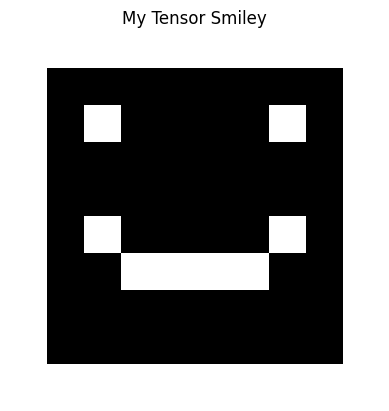

In [30]:
import torch
import matplotlib.pyplot as plt

# Step 1: blank canvas (10x10 grid of zeros = black image)
face = torch.zeros(10, 10)

# Step 2: draw the face border using simple slicing (done for you)
face[0, :] = 1     # top row
face[9, :] = 1     # bottom row
face[:, 0] = 1     # left column
face[:, 9] = 1     # right column

# Step 3: eyes
# TODO: set two single pixels to 1 to make the left and right eye
face[2, 2] = 1
face[2, 7] = 1



# Step 4: mouth
# TODO: set a row of pixels to 1 to make a straight-line mouth
# Hint: use slicing like face[row, start:end] = 1
face[5,2] = 1
face[5,7] = 1
face[6,3:7]=1



# Step 5: show the result
plt.imshow(face, cmap='gray')
plt.title("My Tensor Smiley")
plt.axis('off')
plt.show()

In [31]:
x=torch.tensor([[0,0],[0,1],[1,0],[1,1]],dtype=torch.float32)
# y=torch.tensor([[0],[0],[0],[1]],dtype=torch.float32)

In [32]:
model=nn.Linear(2,1,bias=False)

In [33]:
model.weight.data=torch.tensor([[1.,1.]])

In [34]:
z=model(x)

In [35]:
z

tensor([[0.],
        [1.],
        [1.],
        [2.]], grad_fn=<MmBackward0>)

In [36]:
pred=(z==1).int()

In [37]:
pred

tensor([[0],
        [1],
        [1],
        [0]], dtype=torch.int32)

In [38]:
z=torch.linspace(-6,6,1201,requires_grad=True)
z

tensor([-6.000000, -5.990000, -5.980000,  ...,  5.980000,  5.990000,
         6.000000], requires_grad=True)

In [39]:
step_y=(z>=0).float()
sigmoid_y=torch.sigmoid(z)
tanh_y=torch.tanh(z)

In [40]:
step_grad=torch.zeros_like(z)
sigmoid_grad=torch.zeros_like(z)
tanh_grad=torch.zeros_like(z)

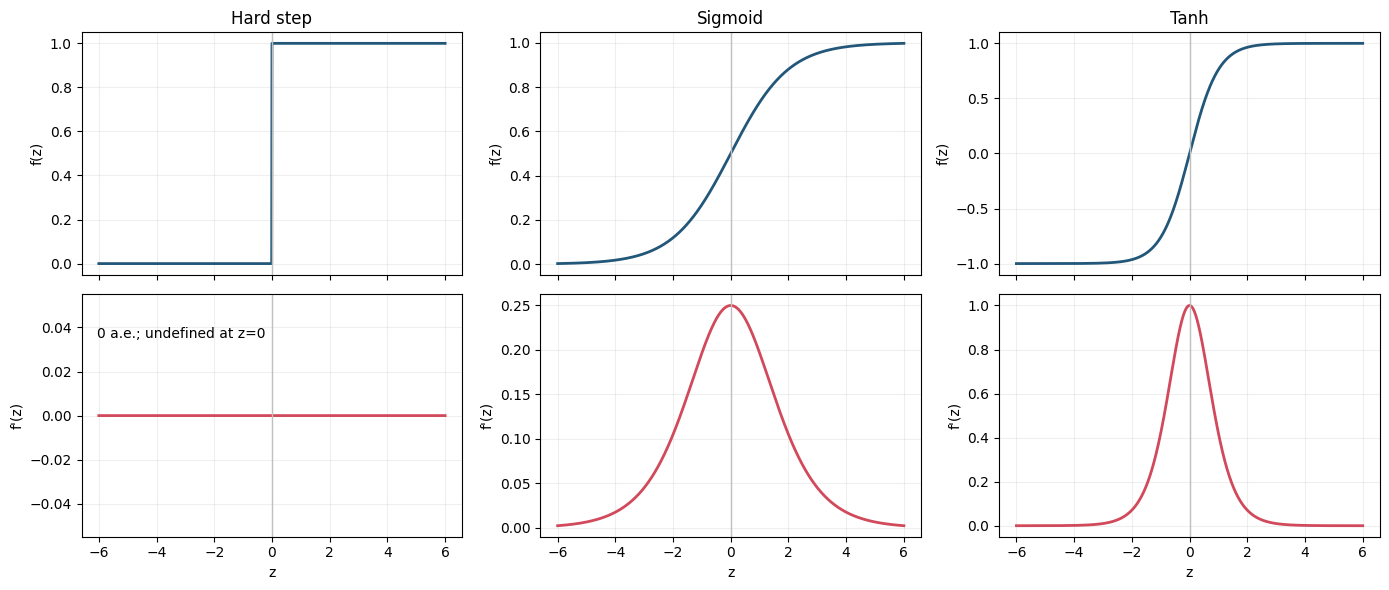

At z=0: sigmoid'=0.25, tanh'=1.00
Hard-step output requires grad? False


In [41]:
z = torch.linspace(-6, 6, 1201, requires_grad=True)

step_y = (z >= 0).float()
sigmoid_y = torch.sigmoid(z)
tanh_y = torch.tanh(z)

step_grad = torch.zeros_like(z)
sigmoid_grad = torch.autograd.grad(sigmoid_y.sum(), z)[0]
tanh_grad = torch.autograd.grad(tanh_y.sum(), z)[0]

names = ["Hard step", "Sigmoid", "Tanh"]
outputs = [step_y.detach(), sigmoid_y.detach(), tanh_y.detach()]
grads = [step_grad.detach(), sigmoid_grad.detach(), tanh_grad.detach()]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for col, (name, out, grad) in enumerate(zip(names, outputs, grads)):
    axes[0, col].plot(z.detach(), out, color="#22577A", linewidth=2)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("f(z)")
    axes[1, col].plot(z.detach(), grad, color="#D1495B", linewidth=2)
    axes[1, col].set_ylabel("f'(z)")
    axes[1, col].set_xlabel("z")
    for ax in axes[:, col]:
        ax.axvline(0, color="0.75", linewidth=1)
        ax.grid(alpha=0.2)
axes[1, 0].text(0.04, 0.82, "0 a.e.; undefined at z=0", transform=axes[1, 0].transAxes)
plt.tight_layout()
plt.show()

center = len(z) // 2
print(f"At z=0: sigmoid'={sigmoid_grad[center].item():.2f}, tanh'={tanh_grad[center].item():.2f}")
print("Hard-step output requires grad?", step_y.requires_grad)

In [42]:

A1_READY = True  # Change to True after completing the TODOs.

def student_probe(name, value):
    # TODO 1: create a scalar float tensor z that tracks gradients
    z = torch.tensor(value, requires_grad=True,dtype=torch.float32)

    # TODO 2: apply the requested activation
    if name == "sigmoid":
        activation = torch.sigmoid(z)
    elif name == "tanh":
        activation = torch.tanh(z)
    else:
        raise ValueError("name must be 'sigmoid' or 'tanh'")

    # TODO 3: ask autograd for d(activation)/dz
    gradient = torch.autograd.grad(activation.sum(),z)[0]

    # TODO 4: return two Python numbers
    return activation.item(), gradient.item()

if not A1_READY:
    print("Complete student_probe, change A1_READY to True, and run again.")
else:
    s0 = student_probe("sigmoid", 0.0)
    t0 = student_probe("tanh", 0.0)
    assert math.isclose(s0[0], 0.5, abs_tol=1e-6)
    assert math.isclose(s0[1], 0.25, abs_tol=1e-6)
    assert math.isclose(t0[0], 0.0, abs_tol=1e-6)
    assert math.isclose(t0[1], 1.0, abs_tol=1e-6)
    print("Tests passed!")
    for value in [-4.0, 0.0, 4.0]:
        print(value, student_probe("sigmoid", value), student_probe("tanh", value))

Tests passed!
-4.0 (0.01798621006309986, 0.01766270585358143) (-0.9993293285369873, 0.0013408930972218513)
0.0 (0.5, 0.25) (0.0, 1.0)
4.0 (0.9820137619972229, 0.017662733793258667) (0.9993293285369873, 0.0013408930972218513)


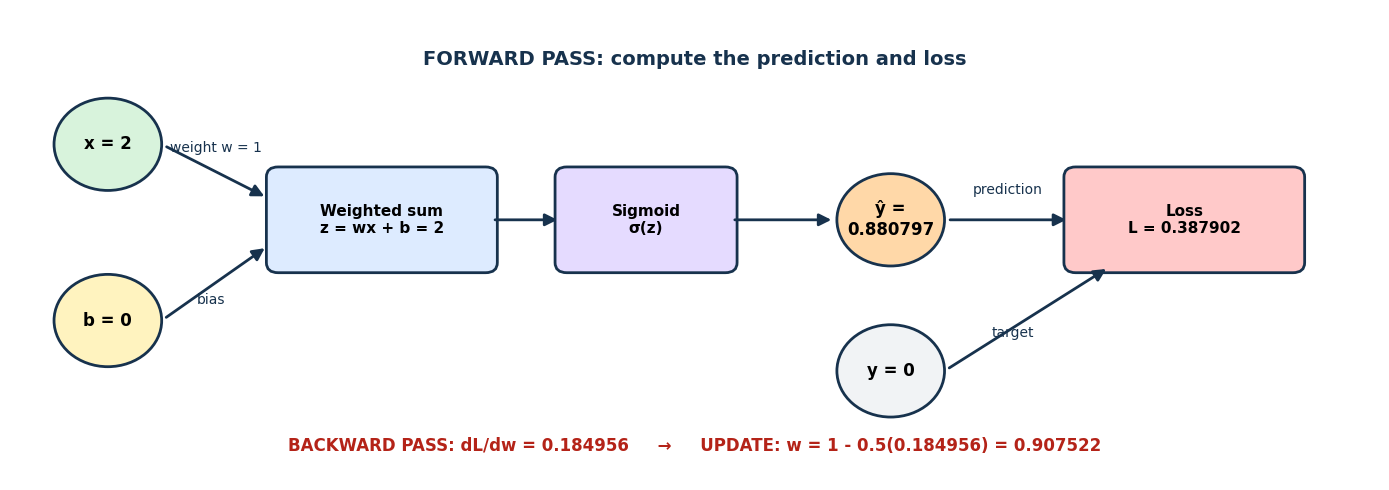

In [43]:
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(-0.6, 5)
ax.axis("off")

def circle_node(xy, text, color):
    node = Circle(xy, 0.55, facecolor=color, edgecolor="#17324D", linewidth=2)
    ax.add_patch(node)
    ax.text(*xy, text, ha="center", va="center", fontsize=12, fontweight="bold")

def box_node(xy, width, text, color):
    x0, y0 = xy[0] - width / 2, xy[1] - 0.55
    node = FancyBboxPatch(
        (x0, y0), width, 1.1,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=color, edgecolor="#17324D", linewidth=2,
    )
    ax.add_patch(node)
    ax.text(*xy, text, ha="center", va="center", fontsize=11, fontweight="bold")

def arrow(start, end, label=None, label_xy=None, color="#17324D"):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=18,
        linewidth=2, color=color, shrinkA=4, shrinkB=4,
    ))
    if label:
        lx, ly = label_xy or ((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.25)
        ax.text(lx, ly, label, ha="center", va="center", fontsize=10, color=color)

# Forward-pass nodes with the lecture values.
circle_node((1.0, 3.4), "x = 2", "#D8F3DC")
circle_node((1.0, 1.3), "b = 0", "#FFF3BF")
box_node((3.8, 2.5), 2.2, "Weighted sum\nz = wx + b = 2", "#DDEBFF")
box_node((6.5, 2.5), 1.7, "Sigmoid\nσ(z)", "#E5DBFF")
circle_node((9.0, 2.5), "ŷ =\n0.880797", "#FFD8A8")
circle_node((9.0, 0.7), "y = 0", "#F1F3F5")
box_node((12.0, 2.5), 2.3, "Loss\nL = 0.387902", "#FFC9C9")

arrow((1.55, 3.4), (2.65, 2.75), "weight w = 1", (2.1, 3.35))
arrow((1.55, 1.3), (2.65, 2.2), "bias", (2.05, 1.55))
arrow((4.9, 2.5), (5.65, 2.5))
arrow((7.35, 2.5), (8.45, 2.5))
arrow((9.55, 2.5), (10.85, 2.5), "prediction", (10.2, 2.85))
arrow((9.55, 0.7), (11.25, 1.95), "target", (10.25, 1.15))

ax.text(
    7.0, 4.35,
    "FORWARD PASS: compute the prediction and loss",
    ha="center", fontsize=14, fontweight="bold", color="#17324D",
)
ax.text(
    7.0, -0.25,
    "BACKWARD PASS: dL/dw = 0.184956     →     UPDATE: w = 1 - 0.5(0.184956) = 0.907522",
    ha="center", fontsize=12, fontweight="bold", color="#B42318",
)
plt.tight_layout()
plt.show()

In [44]:

import torch.nn.functional as F



In [45]:
z=torch.linspace(-6,6,1201,requires_grad=True)

In [46]:
relu_y=F.relu(z)
leaky_y=F.leaky_relu(z,negative_slope=0.01)
elu_y=F.elu(z,alpha=1.0)


In [47]:
relu_grad=torch.autograd.grad(relu_y.sum(),z,retain_graph=True)[0]
leaky_grad=torch.autograd.grad(leaky_y.sum(),z,retain_graph=True)[0]


In [48]:
elu_grad=torch.autograd.grad(elu_y.sum(),z,retain_graph=True)[0]

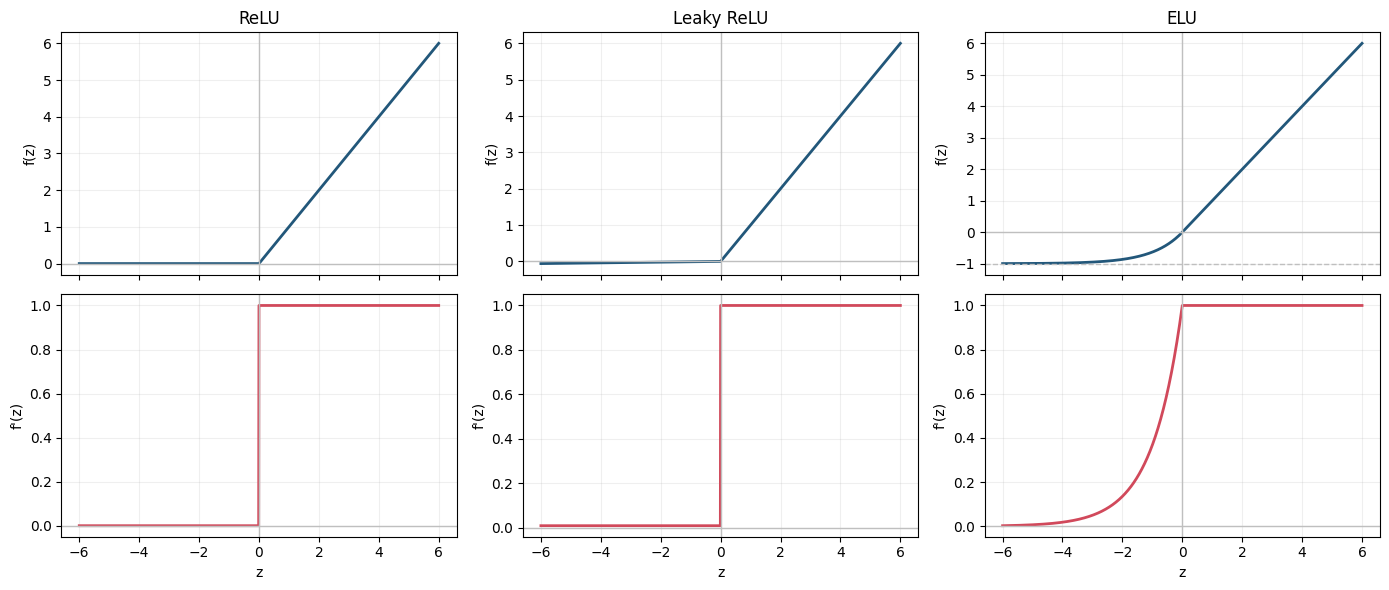

At z=0: ReLU'=1.00, Leaky ReLU'=1.00, ELU'=1.00
At z=-6.0: ReLU=0.000


In [49]:
import matplotlib.pyplot as plt

names = ["ReLU", "Leaky ReLU", "ELU"]
outputs = [relu_y.detach(), leaky_y.detach(), elu_y.detach()]
grads = [relu_grad.detach(), leaky_grad.detach(), elu_grad.detach()]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for col, (name, out, grad) in enumerate(zip(names, outputs, grads)):
    # Plot Function
    axes[0, col].plot(z.detach(), out, color="#22577A", linewidth=2)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("f(z)")

    # Plot Gradient
    axes[1, col].plot(z.detach(), grad, color="#D1495B", linewidth=2)
    axes[1, col].set_ylabel("f'(z)")
    axes[1, col].set_xlabel("z")

    # Add crosshairs for visual clarity
    for ax in axes[:, col]:
        ax.axvline(0, color="0.75", linewidth=1)
        ax.axhline(0, color="0.75", linewidth=1) # <-- FIX: Added y=0 baseline
        ax.grid(alpha=0.2)

# ELU specific asymptote
axes[0, 2].axhline(-1.0, color="0.75", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

# FIX: Cleaned up the 0*0 index to properly reference the first element
center = len(z) // 2
print(f"At z=0: ReLU'={relu_grad[center].item():.2f}, "
      f"Leaky ReLU'={leaky_grad[center].item():.2f}, ELU'={elu_grad[center].item():.2f}")
print(f"At z={z[0].item():.1f}: ReLU={relu_y[0].item():.3f}")

In [50]:
# # 🔧 Your turn — implement Mean Absolute Error manually,
# # then compute it for BOTH the clean and outlier targets.

# def mae_manual(y_true, y_pred):
#     # TODO: replace None with your implementation
#     result = None
#     return result

# # TODO: use your function on both target sets
# mae_clean_manual = None
# mae_outliers_manual = None

# mae_loss_fn = nn.L1Loss()
# mae_clean_builtin = mae_loss_fn(y_pred_t, y_clean_t)
# mae_outliers_builtin = mae_loss_fn(y_pred_t, y_outlier_t)

# if mae_clean_manual is None or mae_outliers_manual is None:
#     print("⚠️  Still returning None — fill in mae_manual above.")
# else:
#     print(f"Clean    -> Your MAE: {mae_clean_manual.item():.4f}   | Built-in: {mae_clean_builtin.item():.4f}")
#     print(f"Outliers -> Your MAE: {mae_outliers_manual.item():.4f}   | Built-in: {mae_outliers_builtin.item():.4f}")
#     print("Match?",
#           torch.allclose(mae_clean_manual, mae_clean_builtin, atol=1e-5) and
#           torch.allclose(mae_outliers_manual, mae_outliers_builtin, atol=1e-5))

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [52]:
seed=42
np.random.seed(42)
torch.manual_seed(42)

In [53]:
df=pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [54]:
df.drop(columns=['id','Unnamed: 32'], inplace=True)

In [55]:
X=df.drop(columns=['diagnosis'])
y=df['diagnosis']

In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=seed)

In [57]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [58]:
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

In [59]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

In [60]:
X_train_tensor=torch.from_numpy(X_train.astype(np.float32))
X_test_tensor=torch.from_numpy(X_test.astype(np.float32))
y_train_tensor=torch.from_numpy(y_train.astype(np.float32))
y_test_tensor=torch.from_numpy(y_test.astype(np.float32))

In [61]:
class MySimpleNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()

    # Input:  (Batch_Size, num_features)  ->  Output: (Batch_Size, 1)
    self.linear = nn.Linear(num_features, 1)

    # squashes the raw score into a probability in (0, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    # features: (Batch_Size, num_features)
    out = self.linear(features)
    out = self.sigmoid(out)
    return out

In [62]:
learning_rate=0.1
epochs=25

In [63]:
import numpy as np
import pandas as pd
import time
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

In [64]:
url = 'https://raw.githubusercontent.com/shivang98/Social-Network-ads-Boost/master/Social_Network_Ads.csv'
df = pd.read_csv(url)[['Age', 'EstimatedSalary', 'Purchased']]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [65]:
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [66]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

In [68]:
X_train_t=torch.tensor(X_train, dtype=torch.float32)
X_test_t=torch.tensor(X_test, dtype=torch.float32)
y_train_t=torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1)
y_test_t=torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)

In [69]:
def build_model():
  return nn.Sequential(
      nn.Linear(2,10),nn.ReLU(),
      nn.Linear(10,10),nn.ReLU(),
      nn.Linear(10,1),nn.Sigmoid()
  )

In [70]:
def fit(model, epochs, batch_size, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        perm = torch.randperm(X_train_t.shape[0])                 # reshuffle the rows each epoch
        epoch_loss = 0.0
        n_batches =  0
        for i in range(0, X_train_t.shape[0], batch_size):        # step through in batch_size chunks
            idx = perm[i:i + batch_size]               # indices of this batch
            xb, yb = X_train_t[idx], y_train_t[idx]    # slice out one batch by hand

            optimizer.zero_grad()             # 1. clear old gradients
            loss = criterion(model(xb), yb)   # 2+3. forward pass + loss L
            loss.backward()                   # 4. backprop -> computes dL/dw
            optimizer.step()                  # 5. update: W_n = W_0 - lr * dL/dw

            epoch_loss += loss.item()         # accumulate to report the epoch average
            n_batches += 1

        print(f'Epoch {epoch + 1:2d}/{epochs} - loss: {epoch_loss / n_batches:.4f}')

In [71]:
fit(build_model(), epochs=10, batch_size= 32)


KeyboardInterrupt: 

In [86]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [87]:
torch.manual_seed(42)

In [88]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [89]:
url = "https://media.githubusercontent.com/media/fpleoni/fashion_mnist/master/fashion-mnist_train.csv"
df = pd.read_csv(url)

X = torch.tensor(df.iloc[:, 1:].values, dtype=torch.float32) / 255.0
y = torch.tensor(df.iloc[:, 0].values, dtype=torch.long)

dataset = TensorDataset(X, y)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [90]:
dataset[0]

(tensor([0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.0

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [92]:
# scale pixels to 0-1
X_train = X_train/255.0
X_test = X_test/255.0

In [93]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)

In [94]:
learning_rate=0.1
epochs=100

In [95]:
# instantiate + train the baseline
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # no weight_decay -> no L2

for epoch in range(epochs):
  model.train()  # training mode (Dropout on, BatchNorm updates)
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()
  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f}')

Epoch: 10 , Loss: 0.2722
Epoch: 20 , Loss: 0.2081
Epoch: 30 , Loss: 0.1676
Epoch: 40 , Loss: 0.1371
Epoch: 50 , Loss: 0.1181
Epoch: 60 , Loss: 0.0963
Epoch: 70 , Loss: 0.0835
Epoch: 80 , Loss: 0.0732
Epoch: 90 , Loss: 0.0632
Epoch: 100 , Loss: 0.0738


In [96]:
model.eval()  # evaluation mode (Dropout off, BatchNorm uses running stats)

# accuracy on TRAIN data (data the model has seen)
correct = 0
total = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    _, predicted = torch.max(model(batch_features), 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
base_train_acc = correct/total

# accuracy on TEST data (unseen)
correct = 0
total = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    _, predicted = torch.max(model(batch_features), 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
base_test_acc = correct/total

print(f'train: {base_train_acc:.4f} , test: {base_test_acc:.4f}')

train: 0.9731 , test: 0.8860
